# Этап 3. Создание целевой переменной

**Цель этапа:** создать метки  для каждого блюда — "нужна ли замена" под каждую из 4 целей пользователя.

** цели пользователя:**
1. Похудение
2. Набор массы
3. Баланс/ЗОЖ
4. Контроль сахара

## 1. Загрузка данных

In [1]:
import csv
import pandas as pd

def load_and_fix_csv(path):
    with open(path, 'r', encoding='utf-8') as f:
        reader = csv.reader(f)
        header = next(reader)
        n_cols = len(header)
        fixed_rows = []
        for row in reader:
            if len(row) == n_cols:
                fixed_rows.append(row)
            elif len(row) == n_cols + 1:
                new_row = [row[0] + ',' + row[1]] + row[2:]
                fixed_rows.append(new_row)
    return pd.DataFrame(fixed_rows, columns=header)

df = load_and_fix_csv('../data/daily_food_nutrition.csv')

numeric_cols = ['Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)', 'Fat (g)',
                'Fiber (g)', 'Sugars (g)', 'Sodium (mg)', 'Cholesterol (mg)', 'Water_Intake (ml)']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col])

df['Category_Grouped'] = df['Category'].apply(lambda x: x.split('/')[0])

print('Данные загружены:', df.shape)

Данные загружены: (651, 13)


## 2. Вычисление порогов через перцентили

Для каждого числового признака вычисляем:
- **75-й перцентиль** — граница "высокого" значения (верхние 25% блюд)
- **25-й перцентиль** — граница "низкого" значения (нижние 25% блюд)

In [2]:
features = ['Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)',
            'Fat (g)', 'Sugars (g)', 'Sodium (mg)']

thresholds = {}
for feature in features:
    thresholds[feature] = {
        'high': df[feature].quantile(0.75),
        'low':  df[feature].quantile(0.25)
    }

thresholds_df = pd.DataFrame(thresholds).T
thresholds_df.columns = ['Порог "высокое" (75%)', 'Порог "низкое" (25%)']
print('Пороги для разметки:')
thresholds_df

Пороги для разметки:


,"Порог ""высокое"" (75%)","Порог ""низкое"" (25%)"
Calories (kcal),200.0,40.0
Protein (g),7.0,0.5
Carbohydrates (g),26.0,1.2
Fat (g),10.0,0.2
Sugars (g),6.0,0.4
Sodium (mg),350.0,5.0


## 3. Создание целевых переменных

Правила разметки:
- **Похудение:** калории высокие или сахар высокий или жиры высокие
- **Набор массы:** калории низкие или белок низкий или углеводы низкие
- **Баланс:** сахар высокий или натрий высокий
- **Контроль сахара:** сахар высокий или углеводы высокие

In [3]:
# 1. Похудение
df['target_weightloss'] = (
    (df['Calories (kcal)'] > thresholds['Calories (kcal)']['high']) |
    (df['Sugars (g)']      > thresholds['Sugars (g)']['high'])      |
    (df['Fat (g)']         > thresholds['Fat (g)']['high'])
).astype(int)

# 2. Набор массы
df['target_gainmass'] = (
    (df['Calories (kcal)']   < thresholds['Calories (kcal)']['low']) |
    (df['Protein (g)']       < thresholds['Protein (g)']['low'])     |
    (df['Carbohydrates (g)'] < thresholds['Carbohydrates (g)']['low'])
).astype(int)

# 3. Баланс
df['target_balance'] = (
    (df['Sugars (g)']  > thresholds['Sugars (g)']['high']) |
    (df['Sodium (mg)'] > thresholds['Sodium (mg)']['high'])
).astype(int)

# 4. Контроль сахара
df['target_sugar'] = (
    (df['Sugars (g)']        > thresholds['Sugars (g)']['high'])      |
    (df['Carbohydrates (g)'] > thresholds['Carbohydrates (g)']['high'])
).astype(int)

print('Целевые переменные созданы')
print()

targets = ['target_weightloss', 'target_gainmass', 'target_balance', 'target_sugar']
labels  = ['Похудение', 'Набор массы', 'Баланс/ЗОЖ', 'Контроль сахара']

for target, label in zip(targets, labels):
    count_1 = df[target].sum()
    count_0 = len(df) - count_1
    pct = round(count_1 / len(df) * 100, 1)
    print(f'{label}: нужна замена — {count_1} блюд ({pct}%), не нужна — {count_0} блюд')

Целевые переменные созданы

Похудение: нужна замена — 282 блюд (43.3%), не нужна — 369 блюд
Набор массы: нужна замена — 277 блюд (42.5%), не нужна — 374 блюд
Баланс/ЗОЖ: нужна замена — 280 блюд (43.0%), не нужна — 371 блюд
Контроль сахара: нужна замена — 240 блюд (36.9%), не нужна — 411 блюд


## 4. Визуализация баланса классов

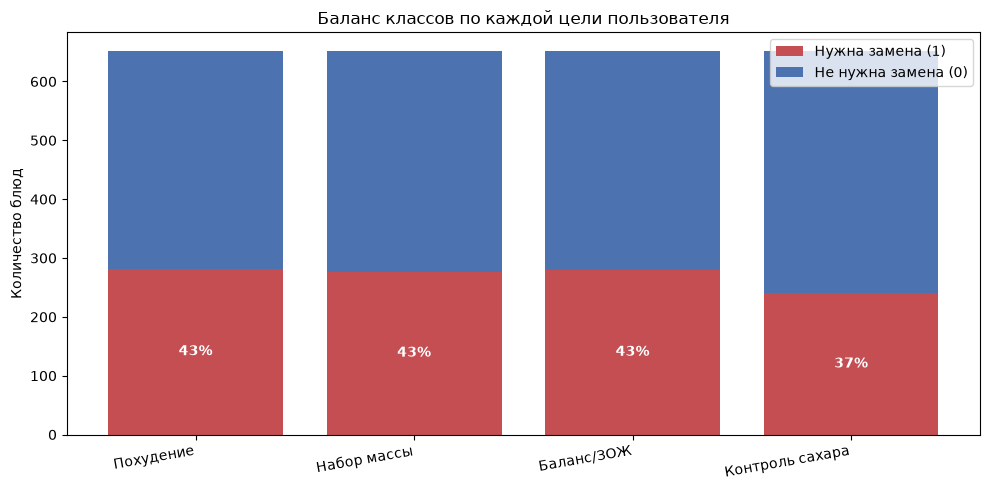

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

counts_need   = [df[t].sum() for t in targets]
counts_noneed = [len(df) - df[t].sum() for t in targets]
x = range(len(labels))

ax.bar(x, counts_need,   label='Нужна замена (1)',    color='#C44E52')
ax.bar(x, counts_noneed, label='Не нужна замена (0)', color='#4C72B0',
       bottom=counts_need)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=10, ha='right')
ax.set_ylabel('Количество блюд')
ax.set_title('Баланс классов по каждой цели пользователя')
ax.legend()

for i, (c1, c0) in enumerate(zip(counts_need, counts_noneed)):
    pct = round(c1 / len(df) * 100)
    ax.text(i, c1 / 2, f'{pct}%', ha='center', va='center',
            color='white', fontweight='bold')

plt.tight_layout()
plt.show()

**Вывод:** для каждой цели получилось достаточно сбалансированное распределение классов

## 5. Пример размеченных данных

In [5]:
cols_show = ['Food_Item', 'Calories (kcal)', 'Sugars (g)', 'Fat (g)', 'Protein (g)',
             'target_weightloss', 'target_gainmass', 'target_balance', 'target_sugar']
df[cols_show].head(10)

,Food_Item,Calories (kcal),Sugars (g),Fat (g),Protein (g),target_weightloss,target_gainmass,target_balance,target_sugar
0,Scrambled Eggs (2 large),180,1.0,14.0,12.0,1,0,0,0
1,Whole Wheat Toast (1 slice),80,2.0,1.0,4.0,0,0,0,0
2,Coffee (black),5,0.0,0.1,0.3,0,1,0,0
3,Banana,105,14.0,0.4,1.3,1,0,1,1
4,Grilled Chicken Salad,350,4.0,20.0,30.0,1,0,1,0
5,Apple,95,19.0,0.3,0.5,1,0,1,1
6,Salmon (4oz grilled),230,0.0,14.0,25.0,1,1,0,0
7,Quinoa (1 cup cooked),222,1.0,3.6,8.0,1,0,0,1
8,Steamed Broccoli (1 cup),55,2.0,0.6,3.7,0,0,0,0
9,Greek Yogurt (plain 1 cup),150,7.0,3.0,25.0,1,0,1,1


## 6. Сохранение датасета с метками

In [6]:
df.to_csv('../data/daily_food_nutrition_labeled.csv', index=False)
print('Файл сохранён: data/daily_food_nutrition_labeled.csv')
print('Размер:', df.shape)
print('Целевые столбцы:', [c for c in df.columns if c.startswith('target_')])

Файл сохранён: data/daily_food_nutrition_labeled.csv
Размер: (651, 17)
Целевые столбцы: ['target_weightloss', 'target_gainmass', 'target_balance', 'target_sugar']


## 7. Выводы по Этапу 3

1. Создано 4 целевые переменные 
2. Пороги определены через 75-й и 25-й перцентили — сравниваем блюда относительно друг друга внутри датасета.
3. Распределение классов сбалансировано для всех целей.
4. Размеченный датасет сохранён в `data/daily_food_nutrition_labeled.csv`.